In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option("display.max_columns", None)

BASE_DIR = Path("..")

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR = BASE_DIR / "reports" / "charts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup Complete")

Setup Complete


In [2]:
nav = pd.read_csv(
    PROCESSED_DIR / "nav_history_clean.csv"
)

fund_master = pd.read_csv(
    RAW_DIR / "01_fund_master.csv"
)

benchmark = pd.read_csv(
    RAW_DIR / "10_benchmark_indices.csv"
)

print("NAV Shape:", nav.shape)
print("Fund Master Shape:", fund_master.shape)
print("Benchmark Shape:", benchmark.shape)

NAV Shape: (46000, 3)
Fund Master Shape: (40, 15)
Benchmark Shape: (8050, 3)


In [3]:
# Convert dates

nav["date"] = pd.to_datetime(nav["date"])

# Sort properly

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Daily Return

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Remove first NaN row of each fund

daily_returns = nav.dropna(
    subset=["daily_return"]
).copy()

print("Daily Returns Shape:")
print(daily_returns.shape)

daily_returns.head()

Daily Returns Shape:
(45960, 4)


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [4]:
daily_returns.to_csv(
    PROCESSED_DIR / "daily_returns.csv",
    index=False
)

print("daily_returns.csv saved")

daily_returns.csv saved


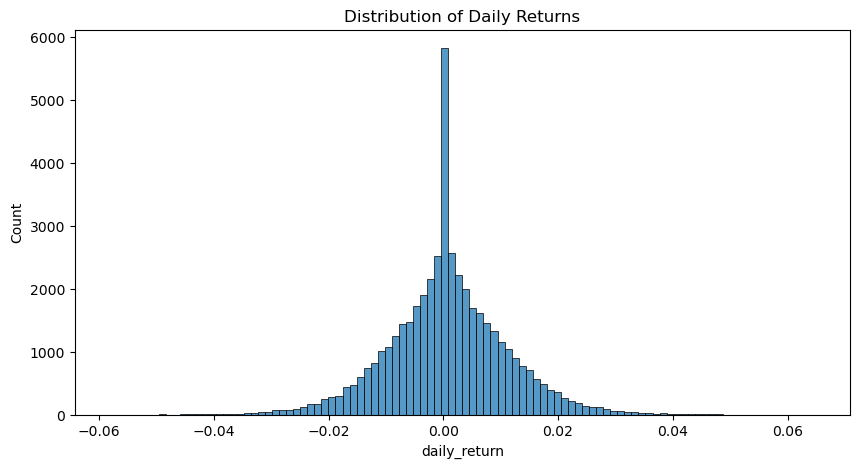

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    daily_returns["daily_return"],
    bins=100
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

In [6]:
# CAGR Calculation (Trading-Day Annualized)

latest_date = nav["date"].max()

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .reset_index(drop=True)
    )

    latest_nav = fund_data.iloc[-1]["nav"]

    result = {"amfi_code": fund}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        historical = fund_data[
            fund_data["date"] <= start_date
        ]

        if historical.empty:
            result[f"CAGR_{years}Y"] = np.nan
            continue

        start_nav = historical.iloc[-1]["nav"]
        actual_start_date = historical.iloc[-1]["date"]

        period_data = fund_data[
            (fund_data["date"] >= actual_start_date)
            & (fund_data["date"] <= latest_date)
        ]

        n_trading_days = period_data["date"].nunique()

        if n_trading_days <= 1:
            result[f"CAGR_{years}Y"] = np.nan
            continue

        cagr = (
            (latest_nav / start_nav)
            ** (252 / n_trading_days)
            - 1
        )

        result[f"CAGR_{years}Y"] = cagr

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

# Convert to percentage
for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_df[col] = cagr_df[col] * 100

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.140290,1.244599,NaN
1,100025,3.561070,3.769016,NaN
2,100033,50.756534,31.074806,NaN
3,101206,45.729997,27.761345,NaN
4,101207,-23.186163,-4.002093,NaN


In [7]:
cagr_df.to_csv(
    "../data/processed/cagr_results.csv",
    index=False
)

# NOTE:
5-year CAGR could not be calculated for several schemes due to insufficient historical NAV data available in the dataset.

In [8]:
RISK_FREE_RATE = 0.065

sharpe_results = []

for fund in daily_returns["amfi_code"].unique():

    fund_returns = daily_returns[
        daily_returns["amfi_code"] == fund
    ]["daily_return"]

    mean_return = fund_returns.mean()

    volatility = fund_returns.std()

    sharpe = (
        (mean_return * 252 - RISK_FREE_RATE)
        /
        (volatility * np.sqrt(252))
    )

    sharpe_results.append(
        {
            "amfi_code": fund,
            "sharpe_ratio": sharpe
        }
    )

sharpe_df = pd.DataFrame(
    sharpe_results
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [9]:
sharpe_df.to_csv(
    PROCESSED_DIR / "sharpe_ratios.csv",
    index=False
)

print("sharpe_ratios.csv saved")

sharpe_ratios.csv saved


# VISUALIZING TOP 10 FUNDS BY SHARP RATIO


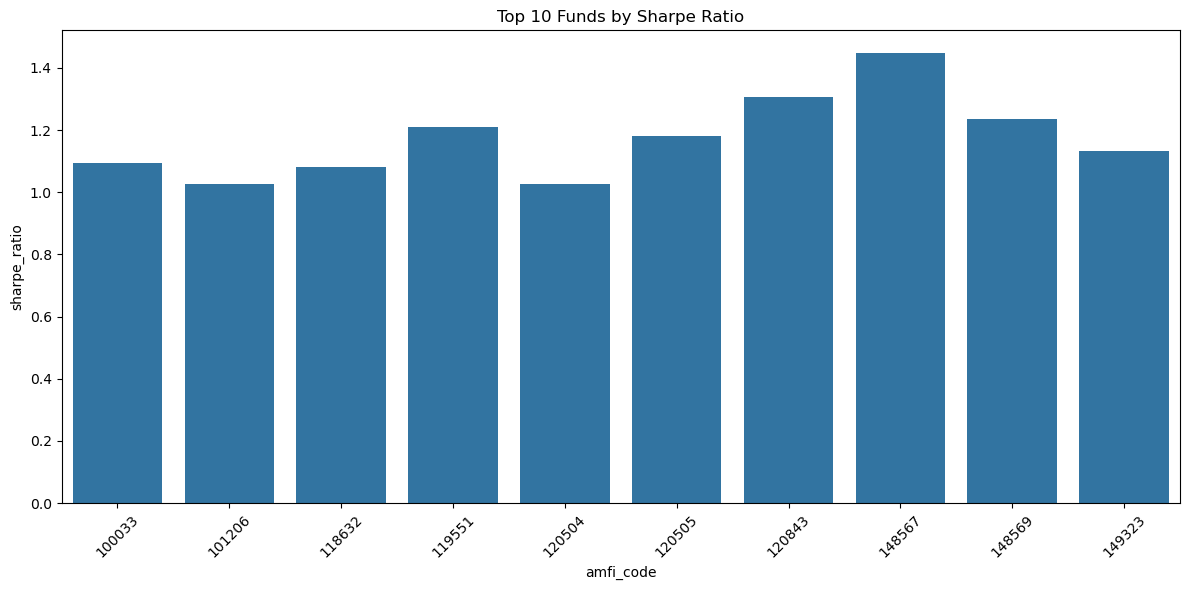

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [11]:
RISK_FREE_RATE = 0.065

sortino_results = []

for fund in daily_returns["amfi_code"].unique():

    fund_returns = daily_returns[
        daily_returns["amfi_code"] == fund
    ]["daily_return"]

    mean_return = fund_returns.mean()

    downside_returns = fund_returns[
        fund_returns < 0
    ]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (mean_return * 252 - RISK_FREE_RATE)
            /
            (downside_std * np.sqrt(252))
        )

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [12]:
sortino_df.to_csv(
    PROCESSED_DIR / "sortino_ratios.csv",
    index=False
)

print("sortino_ratios.csv saved")

sortino_ratios.csv saved


# VISUALIZING TOP 10 FUNDS BY SORTINO RATIO

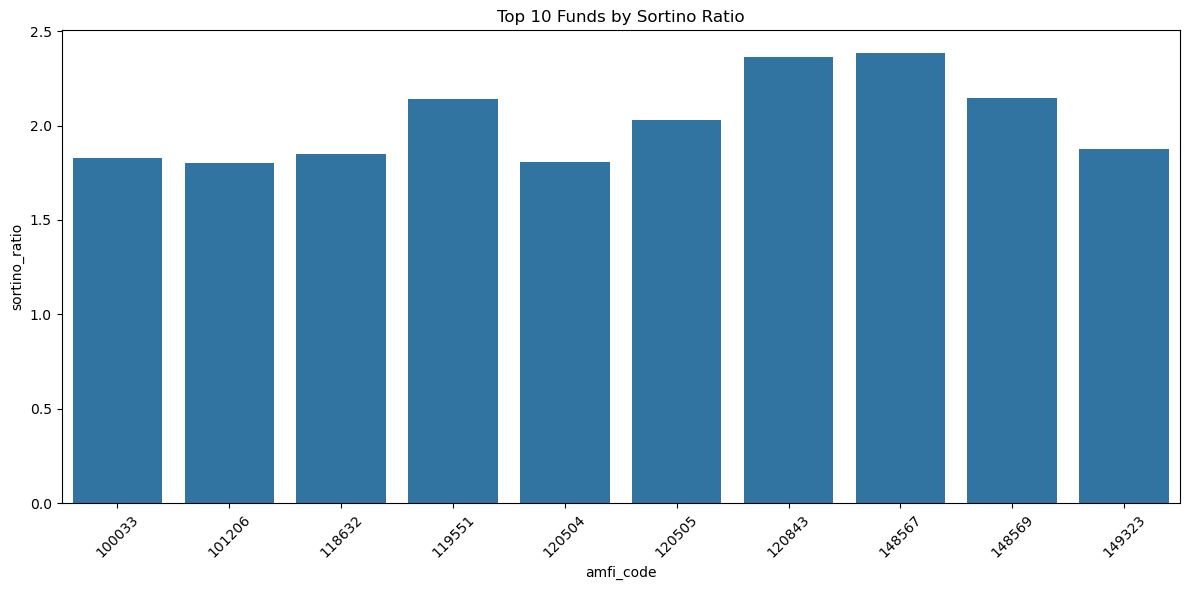

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="amfi_code",
    y="sortino_ratio"
)

plt.title(
    "Top 10 Funds by Sortino Ratio"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# N. ALPHA & BETA ANALYSIS

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_PATH = Path("../data")

nav = pd.read_csv(
    BASE_PATH / "processed" / "nav_history_clean.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    BASE_PATH / "raw" / "10_benchmark_indices.csv",
    parse_dates=["date"]
)

# Use NIFTY50 benchmark
benchmark = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark = benchmark[
    ["date", "benchmark_return"]
].dropna()

alpha_beta_results = []

for amfi_code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == amfi_code
    ].copy()

    fund = fund.sort_values("date")

    fund["fund_return"] = (
        fund["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund[["date", "fund_return"]],
        benchmark,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta = (
        np.cov(
            merged["fund_return"],
            merged["benchmark_return"]
        )[0,1]
        /
        np.var(
            merged["benchmark_return"]
        )
    )

    alpha = (
        merged["fund_return"].mean()
        -
        beta *
        merged["benchmark_return"].mean()
    )

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.000144,-0.025932
1,100025,0.000171,-0.016190
2,100033,0.001081,-0.011209
3,101206,0.000849,0.033843
4,101207,0.000429,-0.059908


In [15]:
alpha_beta_df.to_csv(
    BASE_PATH / "processed" / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


# Visualizing Top 10 Alpha Funds

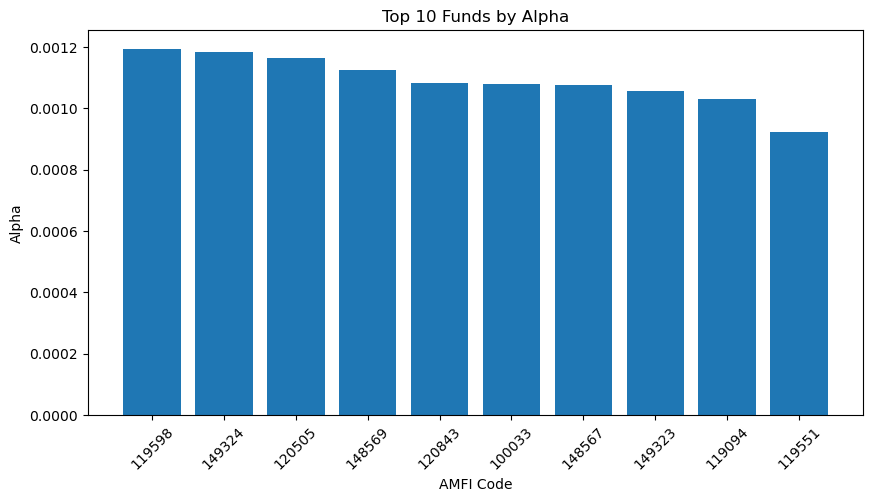

In [16]:
import matplotlib.pyplot as plt

top_alpha = (
    alpha_beta_df
    .sort_values("alpha", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_alpha["amfi_code"].astype(str),
    top_alpha["alpha"]
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.xticks(rotation=45)

plt.show()

# Visualizing Top 10 Beta Funds

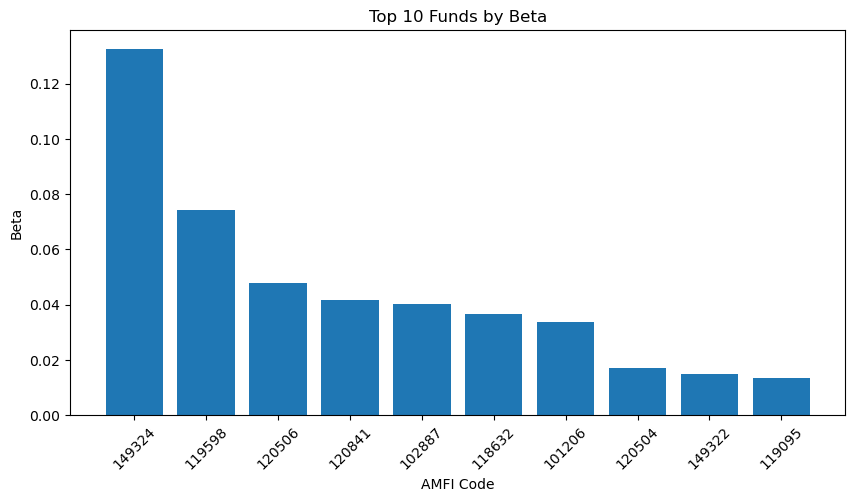

In [17]:
top_beta = (
    alpha_beta_df
    .sort_values("beta", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_beta["amfi_code"].astype(str),
    top_beta["beta"]
)

plt.title("Top 10 Funds by Beta")
plt.xlabel("AMFI Code")
plt.ylabel("Beta")

plt.xticks(rotation=45)

plt.show()

In [18]:
# Maximum Drawdown

drawdown_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date").copy()

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown": max_dd,
        "worst_date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [19]:
drawdown_df.to_csv(
    BASE_PATH / "processed" / "max_drawdown.csv",
    index=False
)

In [20]:
# load exp ratio
scheme_perf = pd.read_csv(
    BASE_PATH / "raw" / "07_scheme_performance.csv"
)

In [21]:
# creating ranks
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code","alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    scheme_perf[["amfi_code","expense_ratio_pct"]],
    on="amfi_code"
)

In [22]:
# ranking
scorecard["return_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [23]:
# composite score
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

In [24]:
# convert 0-100
scorecard["fund_score"] = 100 * (
    scorecard["fund_score"].max()
    - scorecard["fund_score"]
) / (
    scorecard["fund_score"].max()
    - scorecard["fund_score"].min()
)

In [25]:
scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False
)

# creating fund score because i dint founf any attribute like fund score in  07_schema_performance

In [26]:
scorecard["fund_score"] = (
      scorecard["return_rank"]   * 0.30
    + scorecard["sharpe_rank"]   * 0.25
    + scorecard["alpha_rank"]    * 0.20
    + scorecard["expense_rank"]  * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

In [27]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,sharpe_ratio,alpha,max_drawdown,worst_date,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
7,102886,-16.211445,-0.739161,NaN,-0.205832,0.000115,-0.280011,2026-04-27,1.51,37.0,36.0,40.0,24.5,35.0,35.275
0,100016,-2.140290,1.244599,NaN,-0.201517,0.000144,-0.247344,2022-09-15,1.55,35.0,35.0,39.0,32.0,34.0,35.250
17,119095,-41.564987,-11.298788,NaN,-0.075974,0.000181,-0.516778,2026-05-11,1.38,40.0,33.0,37.0,17.0,39.0,34.100
4,101207,-23.186163,-4.002093,NaN,0.162661,0.000429,-0.354469,2026-05-11,1.53,39.0,28.0,27.0,28.5,38.0,32.175
14,119092,1.547229,0.506410,NaN,0.030785,0.000277,-0.144016,2025-02-07,1.64,36.0,31.0,30.0,39.5,15.0,31.975
22,119599,13.381346,-1.288300,NaN,-0.057187,0.000201,-0.525742,2025-10-28,0.72,38.0,32.0,36.0,5.5,40.0,31.425
29,120842,21.556668,7.459051,NaN,0.076000,0.000312,-0.240035,2024-10-17,1.56,28.0,30.0,29.0,33.0,33.0,29.950
1,100025,3.561070,3.769016,NaN,-0.567095,0.000171,-0.043083,2023-07-28,0.56,34.0,39.0,38.0,2.0,4.0,28.250
5,101208,6.951057,6.075517,NaN,-0.815567,0.000241,-0.001622,2023-09-12,0.79,31.0,40.0,33.0,11.0,3.0,27.850
18,119120,5.305739,5.618652,NaN,-0.226575,0.000221,-0.043287,2025-04-01,0.77,32.0,37.0,34.0,9.0,5.0,27.500


In [28]:
scorecard.to_csv(
    BASE_PATH / "processed" / "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [29]:
scorecard["CAGR_5Y"]=scorecard["CAGR_5Y"].fillna(0)

In [30]:
print(scorecard.shape)

(40, 15)


# benchmark comparision (top 5 funds vs nifty 50 & nifty 100)

In [31]:
alpha_beta_df.to_csv(
    BASE_PATH / "processed" / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [32]:
top5 = scorecard.head(5)["amfi_code"].tolist()

In [33]:
# preparing benchmark
benchmark_raw = pd.read_csv(
    BASE_PATH / "raw" / "10_benchmark_indices.csv",
    parse_dates=["date"]
)

nifty50 = benchmark_raw[
    benchmark_raw["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_raw[
    benchmark_raw["index_name"] == "NIFTY100"
].copy()

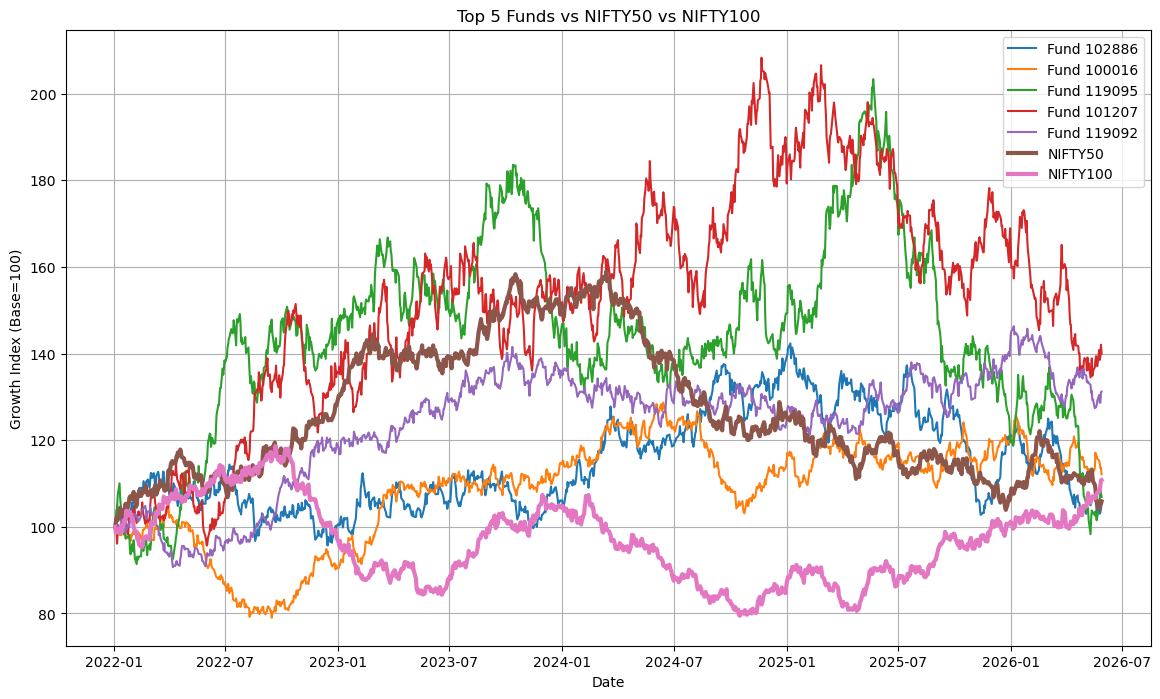

In [34]:
# normalize series
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    if len(fund_data) < 30:
        continue

    base = fund_data["nav"].iloc[0]

    fund_data["normalized"] = (
        fund_data["nav"] / base
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=f"Fund {fund}"
    )

# Nifty50
nifty50 = nifty50.sort_values("date")
nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

# Nifty100
nifty100 = nifty100.sort_values("date")
nifty100["normalized"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 vs NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Growth Index (Base=100)")
plt.legend()
plt.grid(True)

plt.savefig(
    BASE_PATH / "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [35]:
# tracking error
tracking_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_return"] = (
        fund_data["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund_data[
            ["date","fund_return"]
        ],
        benchmark[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    tracking_error = (
        (
            merged["fund_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": tracking_error
    })

tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df.head()

,amfi_code,tracking_error
0,100016,0.196416
1,100025,0.136445
2,100033,0.229755
3,101206,0.191469
4,101207,0.291700


In [36]:
tracking_df.to_csv(
    BASE_PATH / "processed" / "tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved
